In [1]:
import pandas as pd
import numpy as np

z24_path = 'data/Z24.csv'
z24_df = pd.read_csv(z24_path, encoding='utf-8')


first_damage_idx = z24_df[z24_df['label'] == 1].index[0]

print(f"첫 손상 발생 인덱스: {first_damage_idx}")

normal_samples = z24_df.iloc[first_damage_idx - 320 : first_damage_idx]

damaged_samples = z24_df.iloc[first_damage_idx : first_damage_idx + 80]

final_dataset = pd.concat([normal_samples, damaged_samples])


print(f"정상 샘플 형태: {normal_samples.shape}")
print(f"손상 샘플 형태: {damaged_samples.shape}")
print(f"최종 데이터셋 형태: {final_dataset.shape}")

# 데이터 확인
print(final_dataset.head())

print(final_dataset.tail())


첫 손상 발생 인덱스: 3475
정상 샘플 형태: (320, 7)
손상 샘플 형태: (80, 7)
최종 데이터셋 형태: (400, 7)
              datetime        f1        f2        f3         f4    Temp  label
3155  1998-07-12 17:00  3.923324  5.216077  9.937403  10.708015  28.005      0
3156  1998-07-12 18:00  3.917875  5.225691  9.972176  10.768581  28.300      0
3157  1998-07-12 19:00  3.901457  5.202702  9.933047  10.812004  28.195      0
3158  1998-07-12 20:00  3.917261  5.209517  9.959268  10.755461  27.990      0
3159  1998-07-12 21:00  3.925344  5.224739  9.971860  10.594121  27.610      0
             datetime        f1        f2        f3         f4    Temp  label
3550  1998-08-12 1:00  3.896799  5.066790  9.817127  10.362411  34.770      1
3551  1998-08-12 2:00  3.875108  5.018530  9.835471  10.314365  34.030      1
3552  1998-08-12 3:00  3.885586  5.022138  9.773335  10.362288  33.235      1
3553  1998-08-12 8:00  3.885159  4.953294  9.851102  10.315144  30.035      1
3554  1998-08-12 9:00  3.874345  4.965407  9.740600  10.3000

In [2]:
def missing_pattern(X, method="MCAR", fraction=0.2, random_state=42):
    if method == "MCAR":
        return random_nans(X.copy(), fraction=fraction, random_state=random_state)
    elif method == "mode_selected":
        return inject_random_missing_two_modes(X.copy(), fraction=fraction, random_state=random_state)
    else:
        raise ValueError("method must be 'MCAR' or 'mode_selected'")
    
def plot_combined_and_subplots(df, title_prefix, damage_start=320):
    x = np.arange(0, len(df))
    n_modes = df.shape[1]
    colors = plt.cm.tab10(np.linspace(0, 1, n_modes))

    mask_before = x <= damage_start
    mask_after = x >= damage_start  

    # --------------------------------------------------
    # Figure 1: 모든 모드를 한 플롯에 표시
    # --------------------------------------------------
    plt.figure(figsize=(14, 6))

    for i, col in enumerate(df.columns):
        y = df[col].values

        plt.plot(
            x[mask_before],
            y[mask_before],
            color=colors[i],
            linewidth=1.5,
            label=f"Mode {i+1}"
        )

        plt.plot(
            x[mask_after],
            y[mask_after],
            color='red',
            linewidth=1.5,
            alpha=0.8
        )

    plt.axvline(
        x=damage_start,
        color='black',
        linestyle='--',
        linewidth=1.3,
        label=f'Damage start ({damage_start})'
    )

    plt.title(f"After Auto-Scaling: All mode in plot", fontsize=14)
    plt.xlabel("Time sample")
    plt.ylabel("Natural frequency")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # Figure 2: 모드별 subplot을 한 figure에 표시
    # --------------------------------------------------
    fig, axes = plt.subplots(n_modes, 1, figsize=(14, 2.8 * n_modes), sharex=True)

    if n_modes == 1:
        axes = [axes]

    for i, col in enumerate(df.columns):
        y = df[col].values
        ax = axes[i]

        # 손상 전
        ax.plot(
            x[mask_before],
            y[mask_before],
            color=colors[i],
            linewidth=1.5,
            label=f"Mode {i+1}"
        )

        # 손상 후
        ax.plot(
            x[mask_after],
            y[mask_after],
            color='red',
            linewidth=1.5,
            alpha=0.8,
            label='Damaged region' if i == 0 else None
        )

        # 손상 시작선
        ax.axvline(
            x=damage_start,
            color='black',
            linestyle='--',
            linewidth=1.2,
            label=f'Damage start ({damage_start})' if i == 0 else None
        )

        # 손상 전/후 평균선
        mean_before = np.mean(y[mask_before])
        mean_after = np.mean(y[mask_after])

        ax.axhline(
            mean_before,
            color=colors[i],
            linestyle=':',
            linewidth=1.2,
            alpha=0.8
        )
        ax.axhline(
            mean_after,
            color='red',
            linestyle=':',
            linewidth=1.2,
            alpha=0.8
        )

        # 평균값 텍스트
        drop = mean_after - mean_before
        drop_pct = (drop / mean_before) * 100

        ax.text(
            0.99, 0.88,
            f"Before mean = {mean_before:.6f}\nAfter mean = {mean_after:.6f}\nΔ = {drop:.6f} ({drop_pct:.3f}%)",
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

        ax.set_ylabel(f"Mode {i+1}")
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')

    axes[0].set_title(f"{title_prefix}: Mode-wise subplots(After Auto-Scaling)", fontsize=14)
    axes[-1].set_xlabel("Time sample")

    plt.tight_layout()
    plt.show()

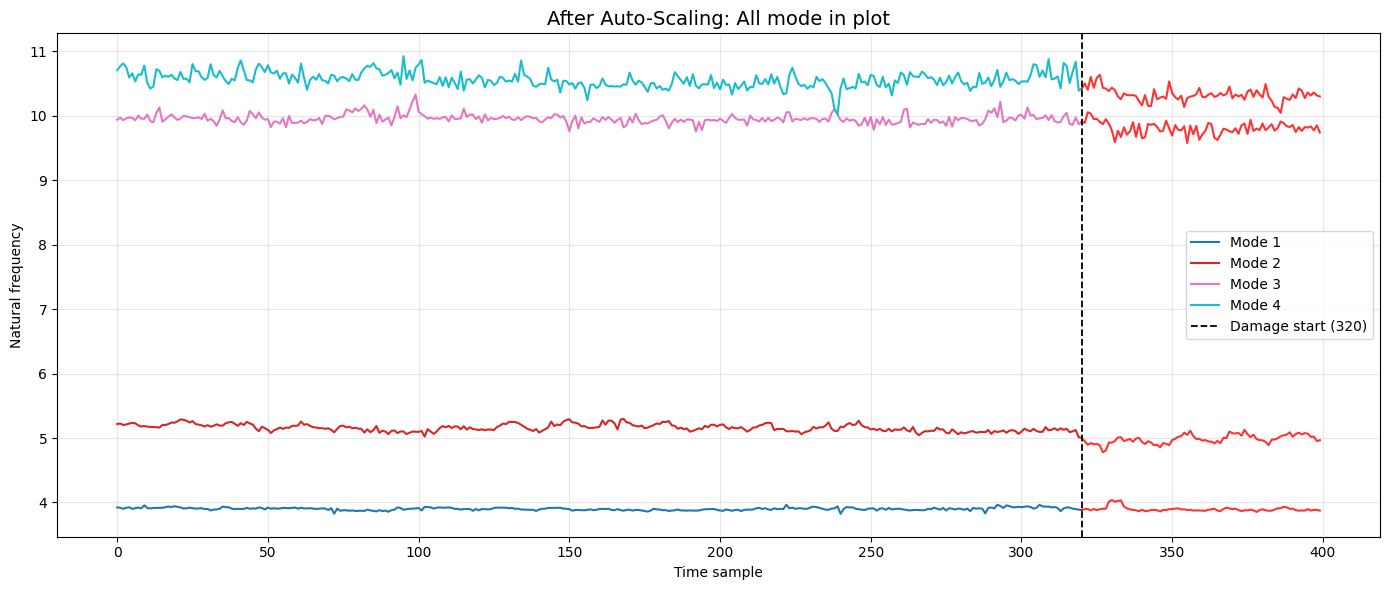

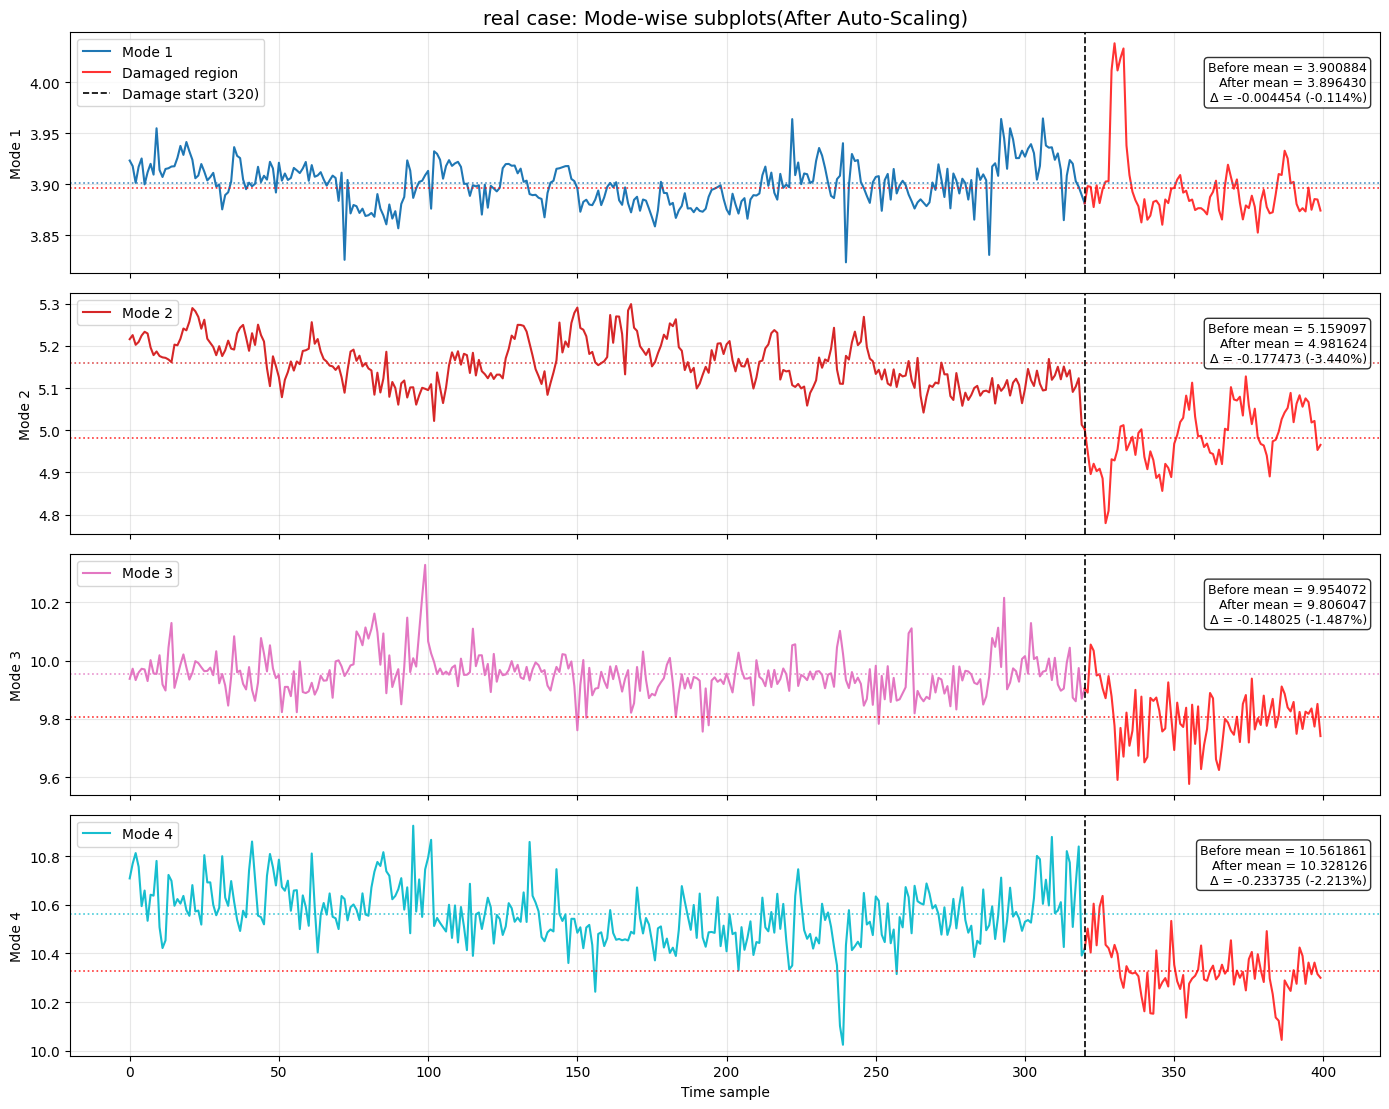

In [3]:
from ppca import ppca_em, ppca_reconstruct_matrix, ppca_reconstruct_optimal
from random_nans import random_nans
from inject_random_missing_two_modes import inject_random_missing_two_modes
from select_retained_nPC import select_retained_nPC
import seaborn as sns
import matplotlib.pyplot as plt

freq_cols = ['f1', 'f2', 'f3', 'f4']
z24_freq = final_dataset[freq_cols].values

z24_freq = pd.DataFrame(z24_freq, columns=freq_cols)

plot_combined_and_subplots(z24_freq, "real case", damage_start=320)


[Fraction 0.1] Explained variance ratio
PC1: eigenvalue=1.370195, ratio=0.381838, cumulative=0.381838
PC2: eigenvalue=1.055149, ratio=0.294043, cumulative=0.675880
PC3: eigenvalue=0.596945, ratio=0.166353, cumulative=0.842233
PC4: eigenvalue=0.566134, ratio=0.157767, cumulative=1.000000


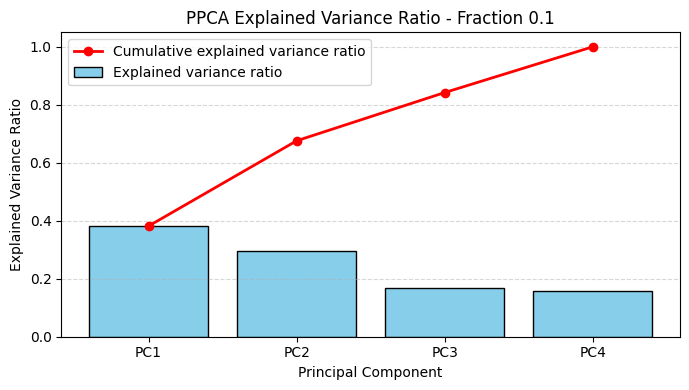

결측률(0.1)에서의 최적차원:2


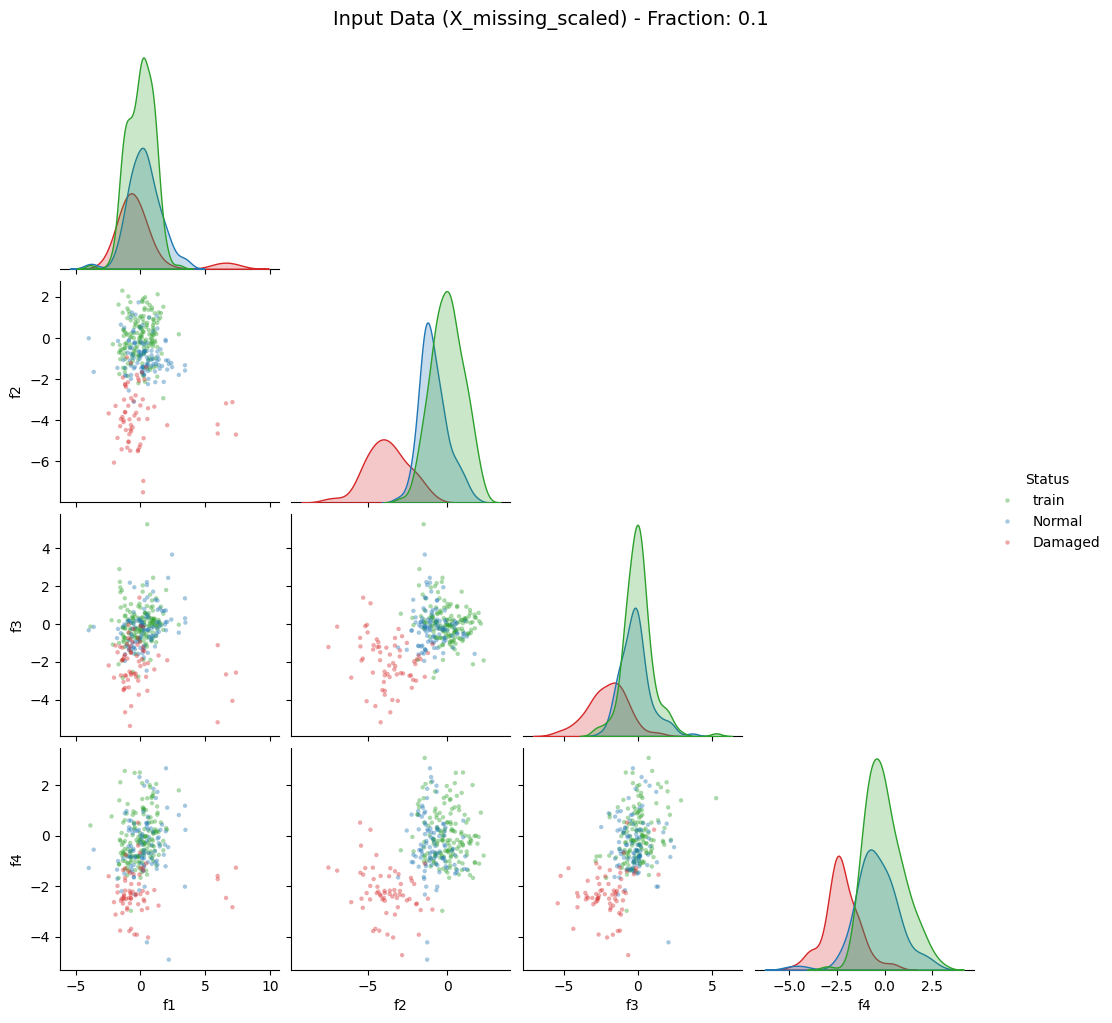

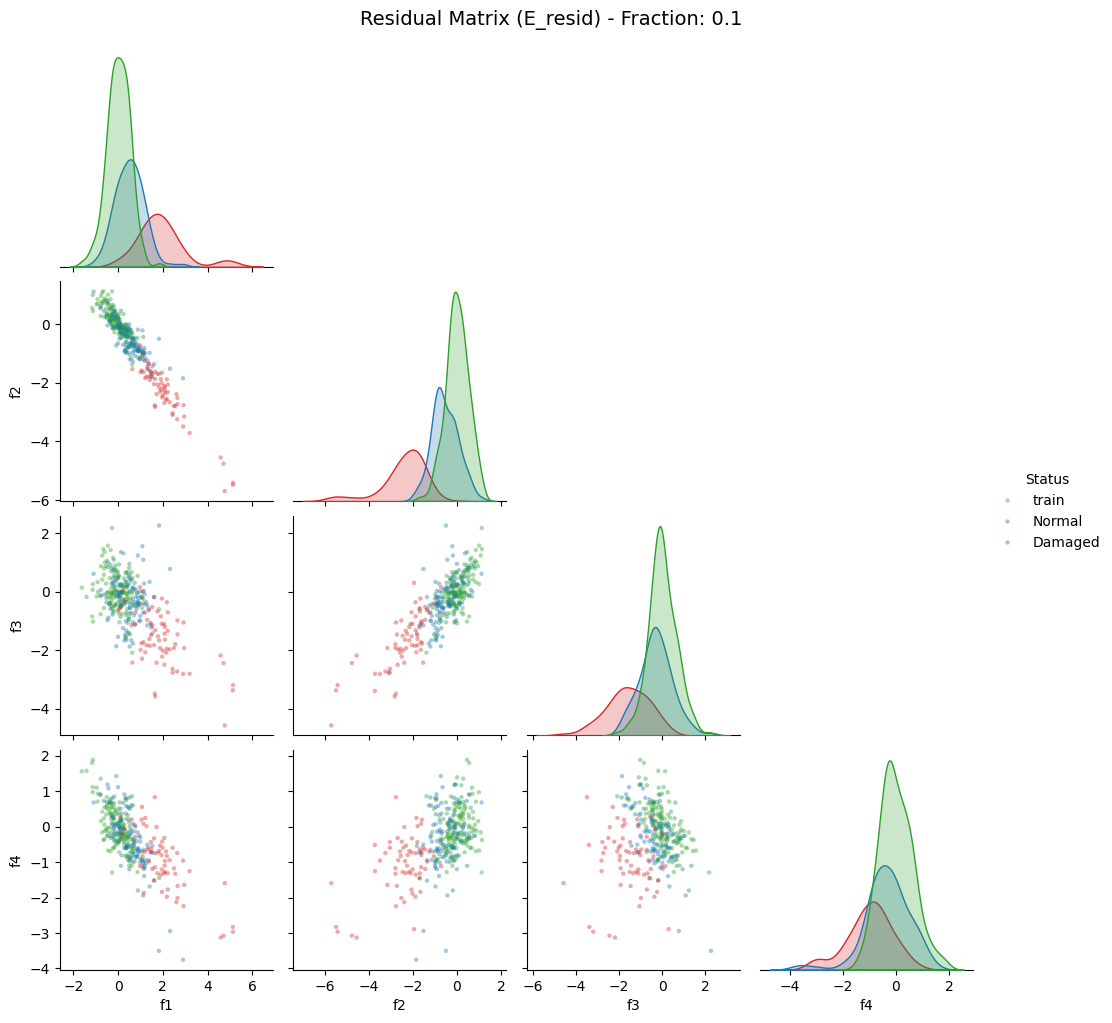


[Fraction 0.1]
means_train:
f1     3.898916
f2     5.177182
f3     9.956715
f4    10.578250
dtype: float64
stds_train:
f1    0.018890
f2    0.052945
f3    0.070566
f4    0.112732
dtype: float64

Residual Covariance Matrix:
          f1        f2        f3        f4
f1  0.268084 -0.227244 -0.084482 -0.228522
f2 -0.227244  0.264229  0.227659  0.069118
f3 -0.084482  0.227659  0.415922 -0.242161
f4 -0.228522  0.069118 -0.242161  0.394269

[Fraction 0.2] Explained variance ratio
PC1: eigenvalue=1.277348, ratio=0.390165, cumulative=0.390165
PC2: eigenvalue=1.034278, ratio=0.315920, cumulative=0.706085
PC3: eigenvalue=0.533426, ratio=0.162935, cumulative=0.869019
PC4: eigenvalue=0.428812, ratio=0.130981, cumulative=1.000000


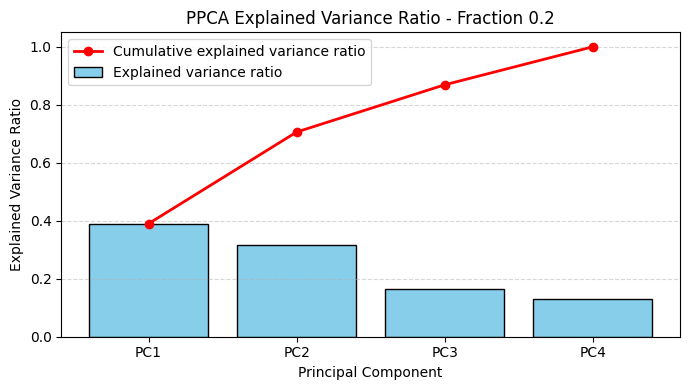

결측률(0.2)에서의 최적차원:2


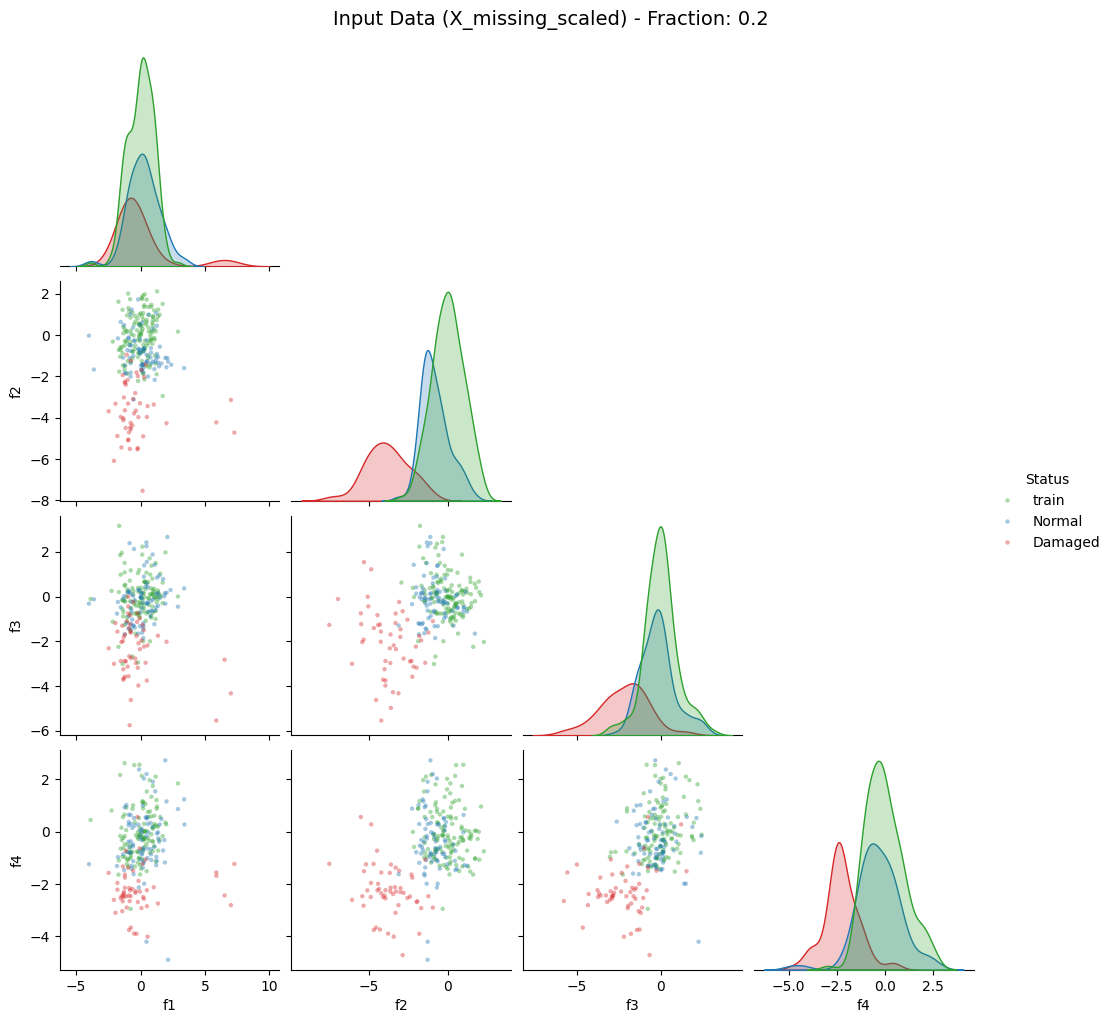

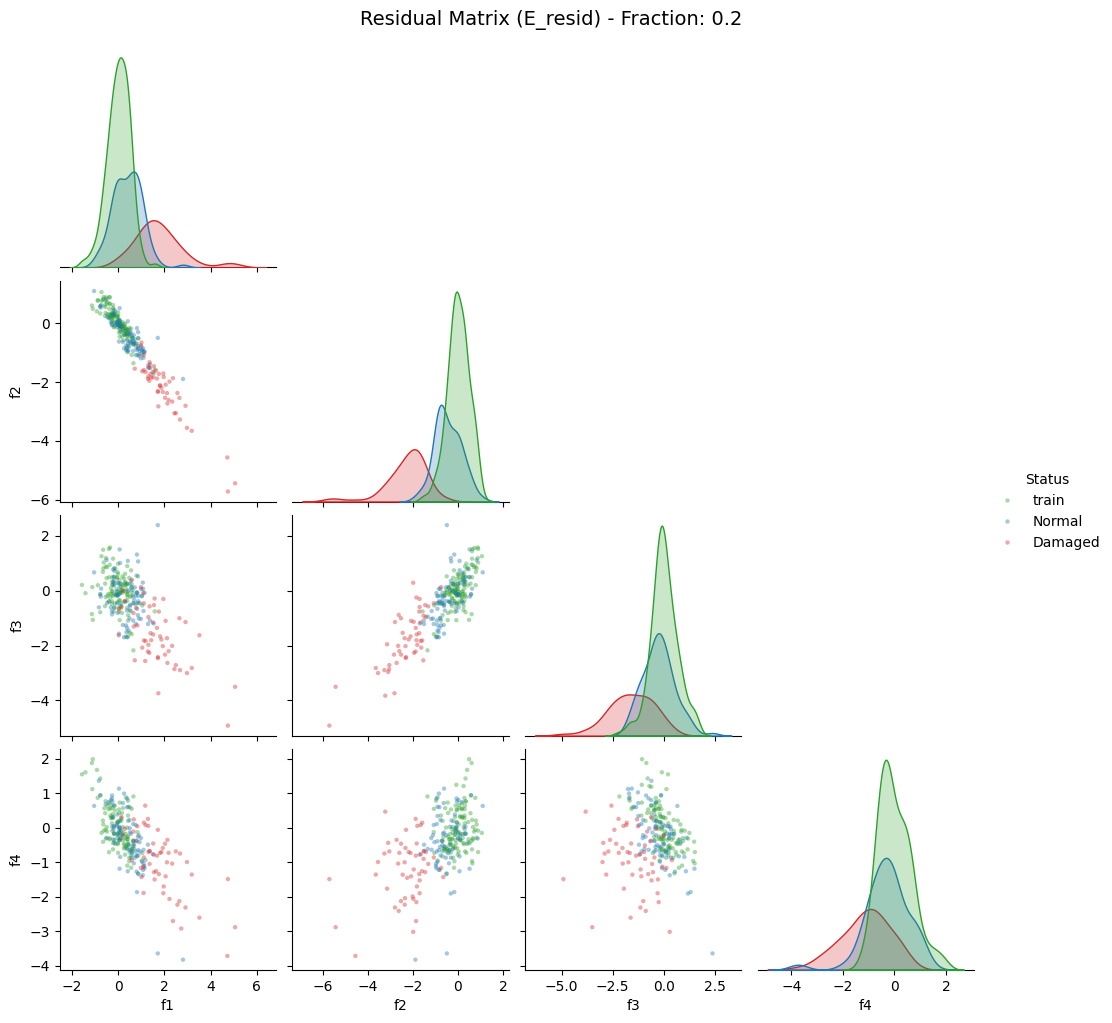


[Fraction 0.2]
means_train:
f1     3.899784
f2     5.177990
f3     9.954045
f4    10.573279
dtype: float64
stds_train:
f1    0.018999
f2    0.052850
f3    0.065682
f4    0.112060
dtype: float64

Residual Covariance Matrix:
          f1        f2        f3        f4
f1  0.241073 -0.207387 -0.096869 -0.218034
f2 -0.207387  0.233651  0.226482  0.049311
f3 -0.096869  0.226482  0.430769 -0.285400
f4 -0.218034  0.049311 -0.285400  0.412829

[Fraction 0.3] Explained variance ratio
PC1: eigenvalue=1.191153, ratio=0.405369, cumulative=0.405369
PC2: eigenvalue=0.979099, ratio=0.333204, cumulative=0.738573
PC3: eigenvalue=0.442227, ratio=0.150497, cumulative=0.889070
PC4: eigenvalue=0.325962, ratio=0.110930, cumulative=1.000000


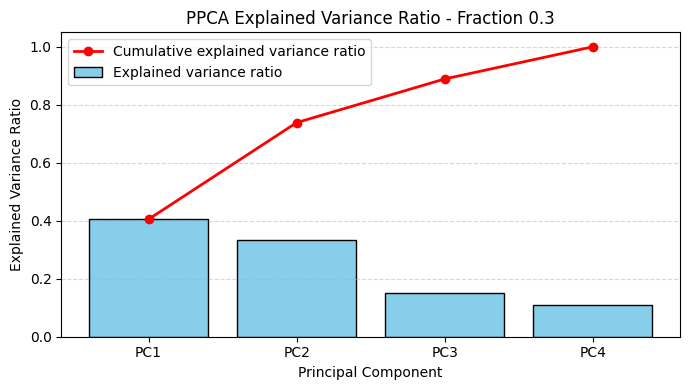

결측률(0.3)에서의 최적차원:2


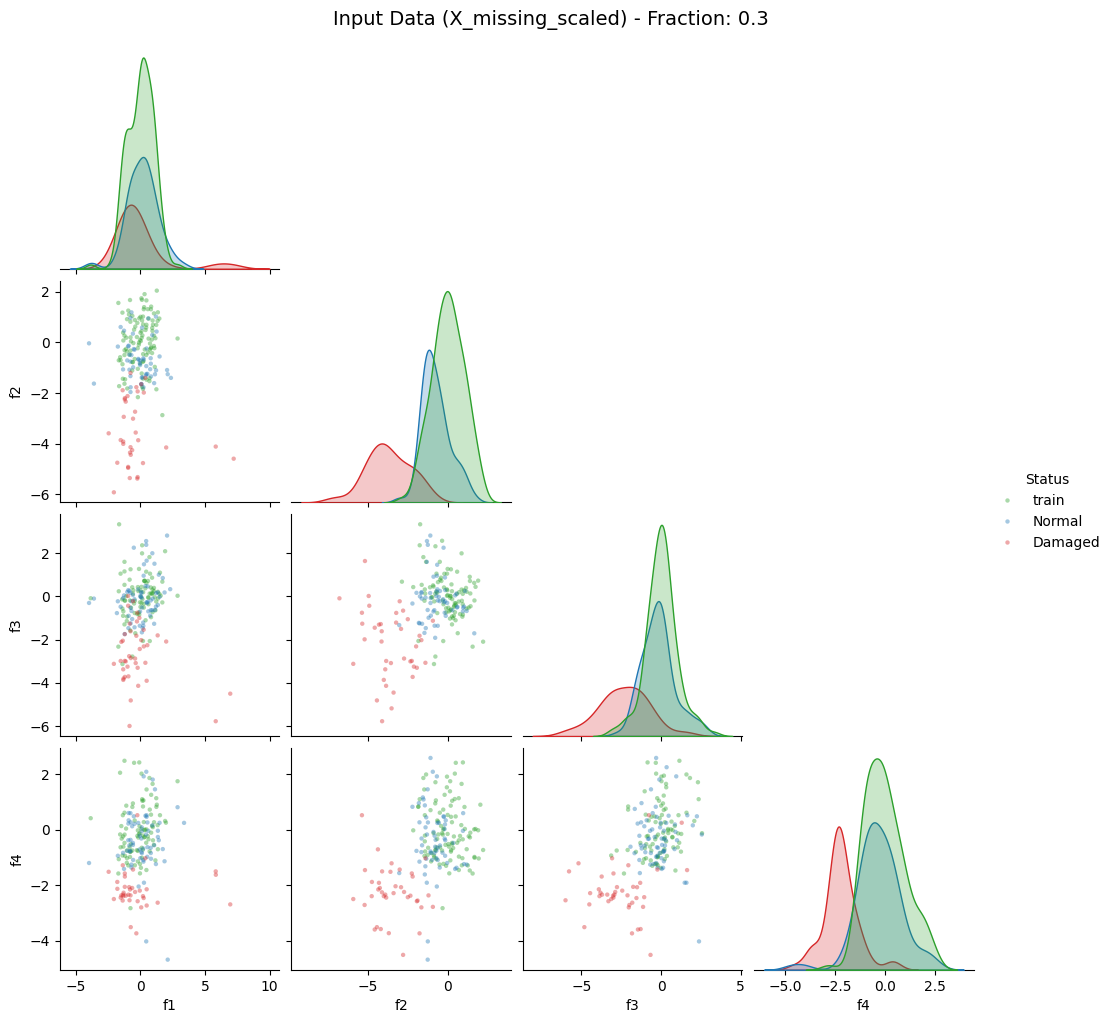

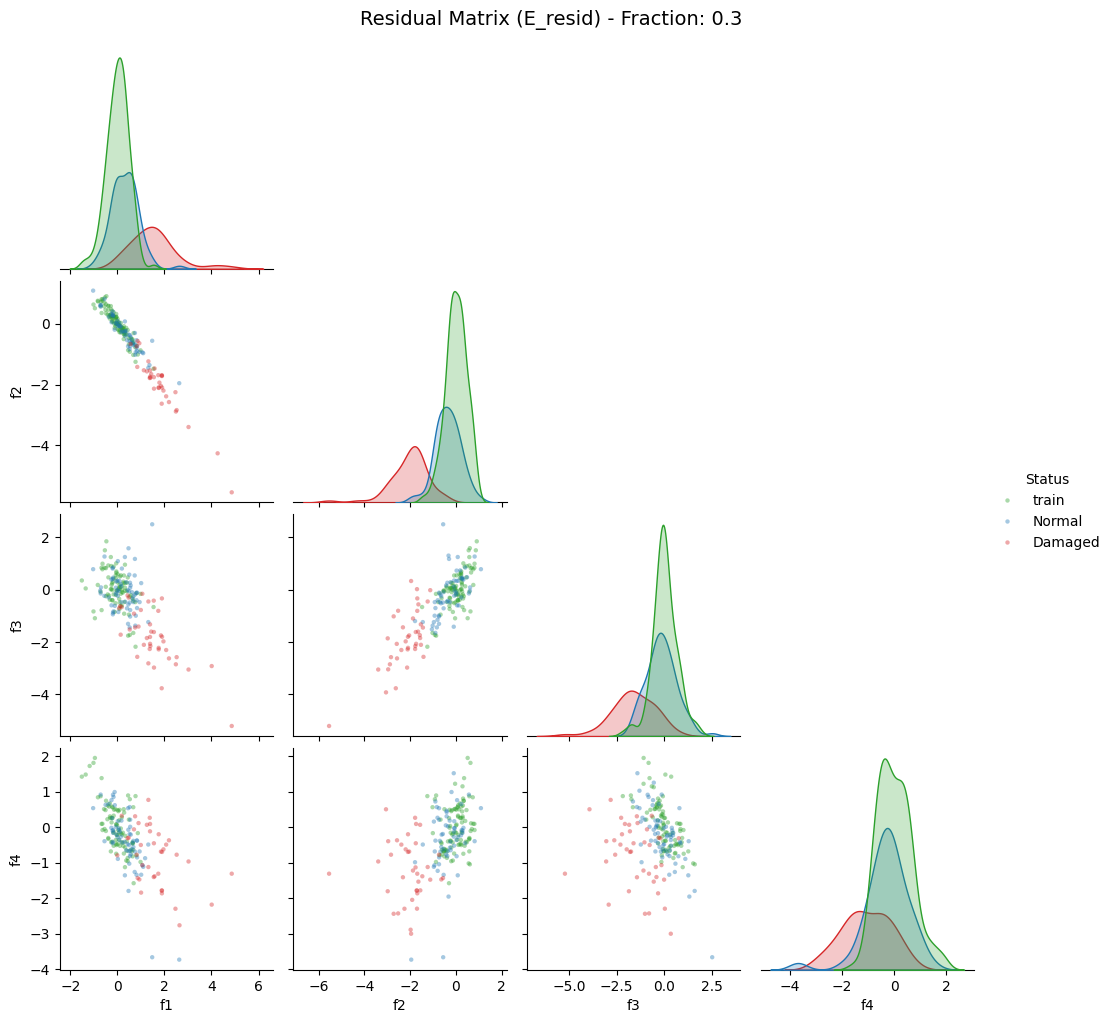


[Fraction 0.3]
means_train:
f1     3.899687
f2     5.178840
f3     9.952713
f4    10.574234
dtype: float64
stds_train:
f1    0.019174
f2    0.054503
f3    0.062766
f4    0.117476
dtype: float64

Residual Covariance Matrix:
          f1        f2        f3        f4
f1  0.224296 -0.204287 -0.120068 -0.217777
f2 -0.204287  0.208583  0.222856  0.063495
f3 -0.120068  0.222856  0.414204 -0.302618
f4 -0.217777  0.063495 -0.302618  0.429920


In [ ]:
from ppca import ppca_em, ppca_reconstruct_matrix, ppca_reconstruct_optimal
from random_nans import random_nans
from inject_random_missing_two_modes import inject_random_missing_two_modes
from select_retained_nPC import select_retained_nPC
import seaborn as sns
import matplotlib.pyplot as plt

freq_cols = ['f1', 'f2', 'f3', 'f4']
z24_freq = final_dataset[freq_cols].values

z24_freq = pd.DataFrame(z24_freq, columns=freq_cols)

n_train = 200
n_damaged = 320

result_labels = []
residual_results = []

for i in range(len(z24_freq)):
    if i >= n_damaged:
        result_labels.append('Damaged')
    else:
        if i>= n_train:
            result_labels.append('Normal')
        else:
            result_labels.append('train')

palette = {
    "Normal": "#1f77b4",
    "train": "#2ca02c",
    "Damaged": "#d62728"
}

missing_method = "MCAR"
recon_method = "optimal"       # 'optimal' or 'latent_mean'
fractions = [0.1, 0.2, 0.3]
mode_names = ['f1', 'f2', 'f3', 'f4']

X_noise_all = z24_freq.values

anisotropy_indices = []

for frac in fractions:
    # 1. 결측 주입
    X_missing_raw = missing_pattern(
        X_noise_all,
        method=missing_method,
        fraction=frac,
        random_state=42
    )

    # DataFrame 보장
    if not isinstance(X_missing_raw, pd.DataFrame):
        X_missing_raw = pd.DataFrame(X_missing_raw, columns=mode_names)

    # 원본 관측 마스크 저장: True = observed, False = missing
    observed_mask = ~X_missing_raw.isna()

    # 2. 결측이 반영된 훈련 데이터 기준 평균/표준편차 계산
    train_missing = X_missing_raw.iloc[:n_train, :]

    means_train = train_missing.mean(axis=0, skipna=True)
    stds_train = train_missing.std(axis=0, skipna=True, ddof=0)

    # 표준편차 0 방지
    stds_train = stds_train.replace(0, 1)

    # 3. 전체 데이터 정규화
    X_missing_scaled = (X_missing_raw - means_train) / stds_train

    n_sample, p = X_missing_scaled.shape
    max_components = p - 1

    X_train = X_missing_scaled.iloc[:n_train, :]

    # 4. PPCA full model
    X_full_recon, W_full, sigma2_full, mu_full = ppca_em(
        X_train.copy(),
        k=max_components
    )

    # 4-1. PPCA 기반 공분산 행렬의 고유값 및 설명분산비
    C_full = W_full @ W_full.T + sigma2_full * np.eye(p)

    eigvals_full = np.sort(np.real(np.linalg.eigvals(C_full)))[::-1]
    explained_variance_ratio = eigvals_full / np.sum(eigvals_full)
    cumulative_explained_variance_ratio = np.cumsum(explained_variance_ratio)

    print(f"\n[Fraction {frac}] Explained variance ratio")
    for idx, (ev, ratio, cum_ratio) in enumerate(
        zip(eigvals_full, explained_variance_ratio, cumulative_explained_variance_ratio), start=1
    ):
        print(
            f"PC{idx}: eigenvalue={ev:.6f}, "
            f"ratio={ratio:.6f}, cumulative={cum_ratio:.6f}"
        )

    # EVR bar plot
    plt.figure(figsize=(7, 4))
    pcs = np.arange(1, len(eigvals_full) + 1)

    plt.bar(pcs, explained_variance_ratio, color='skyblue', edgecolor='black', label='Explained variance ratio')
    plt.plot(
        pcs,
        cumulative_explained_variance_ratio,
        marker='o',
        color='red',
        linewidth=2,
        label='Cumulative explained variance ratio'
    )

    plt.xticks(pcs, [f'PC{i}' for i in pcs])
    plt.ylim(0, 1.05)
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.title(f"PPCA Explained Variance Ratio - Fraction {frac}")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


    model_eigenvalues = np.sort(
        np.real(np.linalg.eigvals(W_full.T @ W_full) + sigma2_full)
    )[::-1]

    # 5. 최적 주성분 수 선택
    k_opt = select_retained_nPC(
        model_eigenvalues,
        nPC_select_algorithm='eigengap'
    )
    k_opt = int(k_opt[0])
    print(f"결측률({frac})에서의 최적차원:{k_opt}")

    # 6. PPCA with optimal components
    X_opt_recon, W_opt, sigma2_opt, mu_opt = ppca_em(
        X_train.copy(),
        k=k_opt
    )

    # 7. 복원
    X_reconstructed = ppca_reconstruct_matrix(
        X_missing_scaled,
        W_opt,
        sigma2_opt,
        mu=mu_opt,
        method=recon_method
    )

    # 8. 잔차 계산
    # 기본 원칙:
    # - 관측된 값: observed - optimal_recon
    # - train 구간의 결측값: full_recon - optimal_recon
    # - normal/damaged 구간의 결측값: NaN 유지
    E_resid = pd.DataFrame(np.nan, index=X_missing_scaled.index, columns=mode_names)

    # (A) 관측된 위치 전체: observed - optimal
    E_obs = X_missing_scaled - X_reconstructed
    E_resid = E_resid.mask(observed_mask, E_obs)

    # (B) train 구간의 결측 위치만: full - optimal
    train_missing_mask = ~observed_mask.iloc[:n_train, :]
    E_train_missing = X_full_recon - X_reconstructed
    E_resid.iloc[:n_train, :] = E_resid.iloc[:n_train, :].mask(
        train_missing_mask,
        E_train_missing
    )

    residual_results.append({
        'fraction': frac,
        'residual_matrix': E_resid.copy(),
        'status': result_labels.copy()
    })

    # 9. DataFrame 변환
    df_missing = pd.DataFrame(X_missing_scaled, columns=mode_names)
    df_missing['Status'] = result_labels

    df_resid = pd.DataFrame(E_resid, columns=mode_names)
    df_resid['Status'] = result_labels

    # 10. 훈련 데이터 잔차 공분산 및 anisotropy index
    train_resid_cov = df_resid.loc[df_resid['Status'] == 'train', mode_names].cov()
    variances = np.diag(train_resid_cov)

    a_index = np.std(variances) / np.mean(variances)
    anisotropy_indices.append(a_index)

    # 11. 시각화
    g_miss = sns.pairplot(
        df_missing,
        hue='Status',
        palette=palette,
        diag_kind='kde',
        corner=True,
        plot_kws={'alpha': 0.4, 's': 10, 'edgecolor': 'none'}
    )
    g_miss.fig.suptitle(
        f"Input Data (X_missing_scaled) - Fraction: {frac}",
        y=1.02,
        fontsize=14
    )
    plt.show()

    g_resid = sns.pairplot(
        df_resid,
        hue='Status',
        palette=palette,
        diag_kind='kde',
        corner=True,
        plot_kws={'alpha': 0.4, 's': 10, 'edgecolor': 'none'}
    )
    g_resid.fig.suptitle(
        f"Residual Matrix (E_resid) - Fraction: {frac}",
        y=1.02,
        fontsize=14
    )
    plt.show()

    print(f"\n[Fraction {frac}]")
    print(f"means_train:\n{means_train}")
    print(f"stds_train:\n{stds_train}")
    print("\nResidual Covariance Matrix:")
    print(train_resid_cov)

In [4]:
for result in residual_results:
    frac = result['fraction']
    resid_mat = result['residual_matrix']
    status_list = result['status']

    # DataFrame 변환
    if not isinstance(resid_mat, pd.DataFrame):
        resid_mat = pd.DataFrame(resid_mat, columns=mode_names)

    # 복사 후 메타정보 추가
    df_temp = resid_mat.copy()
    df_temp['sample_idx'] = np.arange(len(df_temp))
    df_temp['status'] = status_list

    # 컬럼 순서 정리
    df_temp = df_temp[['sample_idx'] + mode_names + ['status']]

    # 파일명 생성
    filename = f"residual_features_frac_{frac:.1f}.csv"

    # 저장
    df_temp.to_csv(filename, index=False, encoding='utf-8-sig')

    print(f"저장 완료: {filename}, shape={df_temp.shape}")

저장 완료: residual_features_frac_0.1.csv, shape=(400, 6)
저장 완료: residual_features_frac_0.2.csv, shape=(400, 6)
저장 완료: residual_features_frac_0.3.csv, shape=(400, 6)
